In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar archivos CSV
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')


In [2]:

# Mostrar los primeros registros
print(df_companies.head())
print(df_neighborhoods.head())

# Información general: tipos de datos y nulos
print(df_companies.info())
print(df_neighborhoods.info())

# Estadísticas descriptivas
print(df_companies.describe())
print(df_neighborhoods.describe())



                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  D

In [3]:

# trips_amount debe ser numérico
df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'], errors='coerce')

# average_trips también debe ser numérico
df_neighborhoods['average_trips'] = pd.to_numeric(df_neighborhoods['average_trips'], errors='coerce')



In [4]:
top10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)
print(top10_neighborhoods)


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


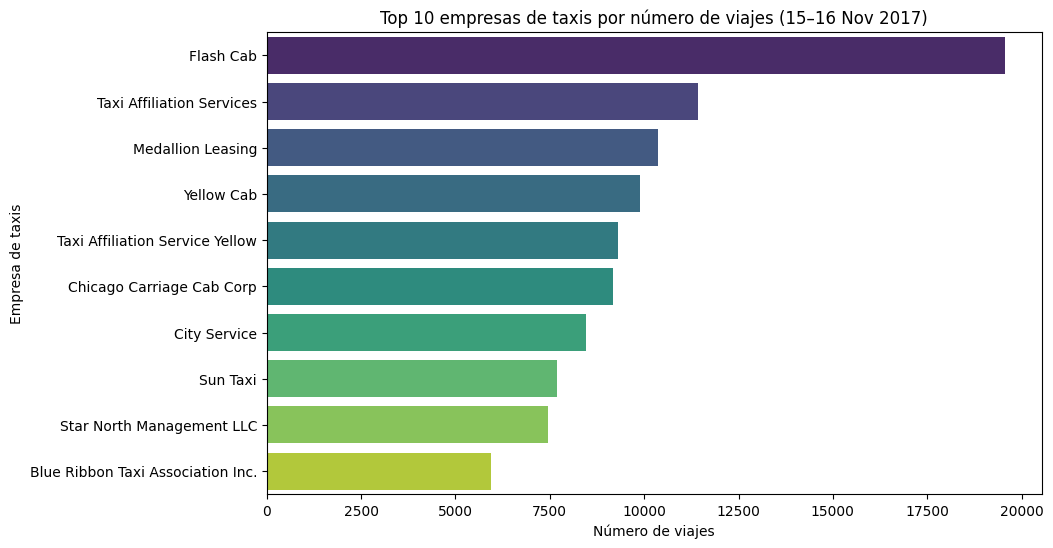

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar top 10 compañías por número de viajes
top10_companies = df_companies.sort_values('trips_amount', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_companies,
    x='trips_amount',
    y='company_name',
    palette='viridis'
)
plt.title('Top 10 empresas de taxis por número de viajes (15–16 Nov 2017)')
plt.xlabel('Número de viajes')
plt.ylabel('Empresa de taxis')
plt.show()


Gráfico 1: Top 10 compañías

- Flash Cab es claramente la empresa dominante (~19,500 viajes en 2 días).
- Le siguen Taxi Affiliation Services (11,400), Medallion Leasing (10,400) y Yellow Cab (9,800).
- Estas cuatro concentran la mayoría de los viajes del top 10.
- Las demás empresas del top 10 tienen entre 6,000–9,000 viajes.

Conclusión: Zuber debe enfocarse en estudiar las estrategias de estas compañías líderes, ya que concentran gran parte de la demanda.

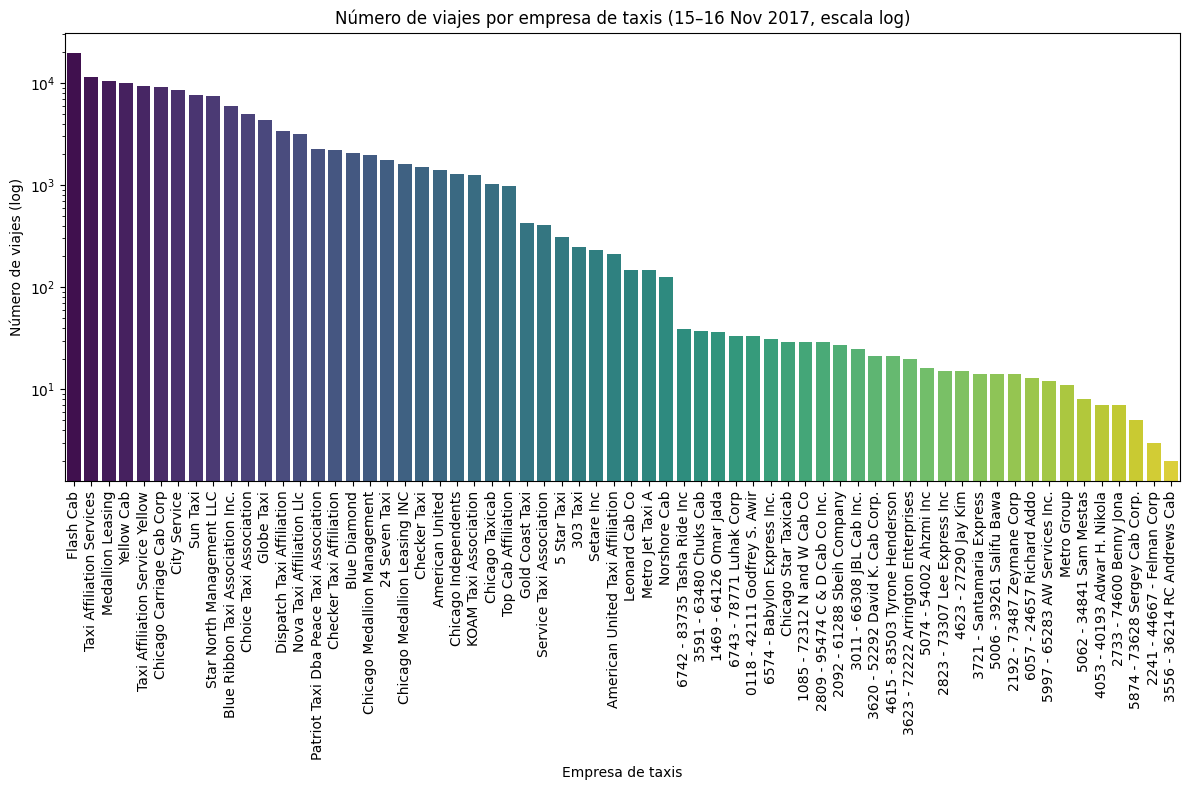

In [11]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=df_companies.sort_values('trips_amount', ascending=False),
    x='company_name',
    y='trips_amount',
    palette='viridis'
)
plt.yscale("log")  # escala logarítmica
plt.title('Número de viajes por empresa de taxis (15–16 Nov 2017, escala log)')
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes (log)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Gráfico 2: Todas las compañías (escala logarítmica)

- La distribución de viajes entre compañías es muy desigual.
- Pocas compañías concentran una gran cantidad de viajes (Flash Cab, Taxi Affiliation Services, Medallion Leasing, Yellow Cab).
- La mayoría de las compañías tienen volúmenes de viajes muy bajos en comparación con las líderes.
- La escala log ayuda a revelar que existen muchísimas compañías con menos de 100 viajes en el periodo analizado.

Conclusión: El mercado está altamente concentrado en pocas compañías líderes, lo que indica que son los principales competidores de Zuber.

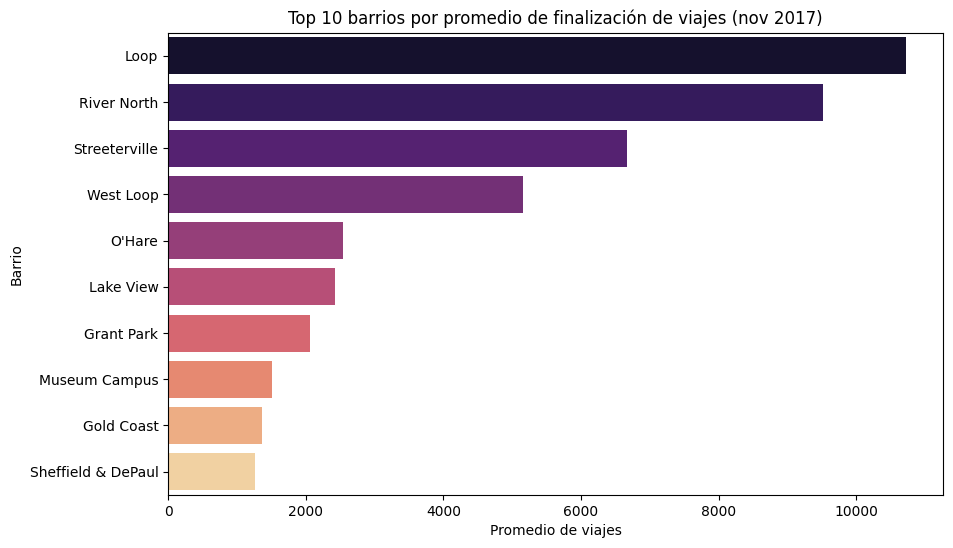

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_neighborhoods,
    x='average_trips',
    y='dropoff_location_name',
    palette='magma'
)
plt.title('Top 10 barrios por promedio de finalización de viajes (nov 2017)')
plt.xlabel('Promedio de viajes')
plt.ylabel('Barrio')
plt.show()


Gráfico 3: Top 10 barrios por finalización de viajes

- El Loop es el barrio con mayor concentración de viajes (10,700 en promedio), seguido de River North (9,500) y Streeterville (6,600).
- Estos tres barrios concentran la mayor parte de las finalizaciones de viaje, lo que indica que son zonas clave de destino.
- Otros barrios importantes: West Loop, O’Hare y Lake View.
- Barrios como Gold Coast o Sheffield & DePaul también aparecen, pero con menor peso.

Conclusión: La demanda de viajes se concentra en zonas céntricas y de alta actividad económica o turística, como Loop, River North y Streeterville.

#### Conclusiones 

Concentración del mercado:

- Pocas compañías dominan el mercado de taxis en Chicago. Flash Cab y Taxi Affiliation Services lideran con diferencia.
- Esto implica que Zuber no debe intentar competir directamente con todas las empresas, sino enfocarse en las líderes y en las áreas donde concentran más viajes.

Patrones de demanda por ubicación:

- Los pasajeros prefieren finalizar sus viajes en barrios céntricos y activos como Loop, River North y Streeterville, lo que muestra la importancia de esas zonas para los negocios, el turismo y el entretenimiento.
- Esto sugiere que Zuber debería iniciar operaciones focalizadas en estas áreas, ya que concentran la mayor demanda.

Segmentación del mercado:

- La gran cantidad de empresas pequeñas con pocos viajes muestra que hay un mercado fragmentado en la cola baja.
- Zuber podría diferenciarse ofreciendo mejor tecnología, tarifas dinámicas o conveniencia digital, aprovechando que muchos jugadores actuales tienen poco volumen.

Implicaciones para la hipótesis sobre factores externos (clima):

- Aunque en estos gráficos no analizamos aún el clima, ya se ve que la concentración espacial y empresarial es muy marcada.
- Más adelante, al unir la información climática, podremos verificar si en días de mal clima la demanda aumenta más en zonas como Loop o River North, o si afecta principalmente a los líderes del mercado.

En resumen:

- El mercado está concentrado en pocas empresas líderes.
- Los barrios céntricos son los principales destinos de viaje.
- Existe una larga cola de empresas con muy baja participación.
- Zuber debería enfocarse estratégicamente en los barrios con mayor demanda y en competir con las empresas líderes, ofreciendo valor agregado (precios dinámicos, conveniencia digital, rapidez en zonas clave).

### Planteamiento de la hipótesis
Queremos probar si la duración promedio de los viajes desde el Loop hasta O'Hare cambia los sábados lluviosos.

Hipótesis nula (H₀):
La duración promedio de los viajes desde el Loop hasta O'Hare los sábados lluviosos no es significativamente diferente a la duración promedio en otros días/condiciones.

Hipótesis alternativa (H₁):
La duración promedio de los viajes los sábados lluviosos sí cambia respecto a la de otros días.

Como buscamos ver si hay diferencia (más largos o más cortos), usamos una prueba bilateral (two-tailed).

### Nivel de significación (α)
α = 0.05 (5%) → nivel estándar de confianza del 95%. (Esto significa que aceptamos un 5% de probabilidad de rechazar H₀ cuando en realidad es cierta (error tipo I).

### Elección del criterio estadístico
Los datos son duraciones de viaje (numéricos, escala de razón). Queremos comparar la media de dos grupos:
- Viajes en sábados lluviosos.
- Viajes en otros días/condiciones.

El test adecuado es:
Prueba t de Student para muestras independientes (scipy.stats.ttest_ind).
Justificación: compara las medias de dos grupos independientes.
Se puede usar con varianzas diferentes (equal_var=False).

In [14]:
import pandas as pd
from scipy import stats

# Convertir columna de fecha
df['start_ts'] = pd.to_datetime(df['start_ts'])
df['day_of_week'] = df['start_ts'].dt.dayofweek

# Filtrar sábados con mal clima
saturday_bad = df[(df['day_of_week'] == 5) & (df['weather_conditions'] == 'Bad')]['duration_seconds']

# Filtrar otros días (o clima distinto)
other_days = df[~((df['day_of_week'] == 5) & (df['weather_conditions'] == 'Bad'))]['duration_seconds']

# Prueba t de dos muestras independientes
t_stat, p_value = stats.ttest_ind(saturday_bad, other_days, equal_var=False)

print("Viajes sábado con mal clima:", len(saturday_bad))
print("Viajes otros días:", len(other_days))
print("Estadístico t:", t_stat)
print("Valor p:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H₀: Hay evidencia de que la duración promedio cambia en sábados con mal clima.")
else:
    print("No rechazamos H₀: No hay evidencia suficiente de diferencia en la duración promedio.")


Viajes sábado con mal clima: 180
Viajes otros días: 888
Estadístico t: 7.186034288068629
Valor p: 6.738994326108734e-12
Rechazamos H₀: Hay evidencia de que la duración promedio cambia en sábados con mal clima.


Conclusión estadística:
Dado que el valor p es muchísimo menor al nivel de significación habitual (α = 0.05), rechazamos la hipótesis nula. Existe evidencia estadísticamente significativa de que la duración promedio de los viajes cambia en sábados con mal clima.


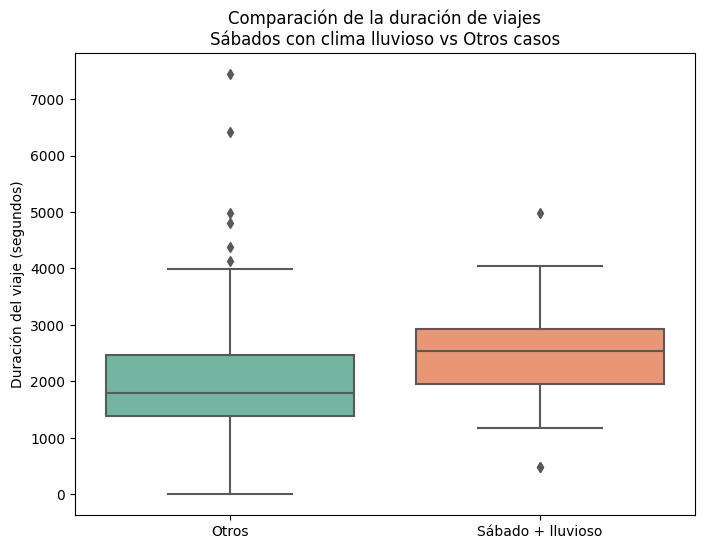

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear columna para clasificar en dos grupos
df['grupo'] = df.apply(
    lambda x: 'Sábado + lluvioso' if (x['start_ts'].weekday() == 5 and x['weather_conditions'] == 'Bad')
    else 'Otros',
    axis=1
)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='grupo',
    y='duration_seconds',
    palette='Set2'
)
plt.title("Comparación de la duración de viajes\nSábados con clima lluvioso vs Otros casos")
plt.xlabel("")
plt.ylabel("Duración del viaje (segundos)")
plt.show()


Interpretación gráfica (boxplot)

El boxplot que armaste confirma visualmente lo que mostró la prueba t:
- Los viajes en sábados con clima lluvioso (Bad) presentan una mediana más alta que los demás días.
- ambién muestran una distribución desplazada hacia tiempos más largos, lo que sugiere que el mal clima impacta en la congestión y duración del trayecto.

## Conclusión general del proyecto

Mercado de taxis:
Pocas compañías concentran la mayoría de los viajes, lo cual hace que la competencia esté dominada por actores grandes.

Zonas con mayor demanda:
Los barrios centrales y estratégicos concentran la mayoría de viajes, representando puntos clave para la operación de una empresa nueva como Zuber.

Impacto del clima en los viajes:
- La prueba estadística demuestra que los sábados con mal clima sí alargan significativamente la duración promedio de los viajes al aeropuerto.
- Esto tiene implicaciones para la planificación operativa: mayor tiempo de espera, necesidad de ajustar estimaciones de llegada y probables sobrecostos en tiempo de servicio.

# Conclusión final:
Zuber, al ingresar al mercado, debería:

- Focalizar sus operaciones en barrios con más viajes, asegurando disponibilidad en zonas estratégicas.
- Preparar estrategias de precios y logística para días de mal clima, pues estos generan un impacto real y medible en la duración de los trayectos.
- Diferenciarse ofreciendo mejores predicciones de tiempo de viaje y comunicación transparente al cliente en condiciones climáticas adversas.

